# Lab 2: Predictive Analysis with Machine Learning


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

## Section 1 -Supervised Learning Regression

### Part 1.1-Load and explore the taxi data

Taxi database shape:  (41202, 13)
First rows:    VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0          

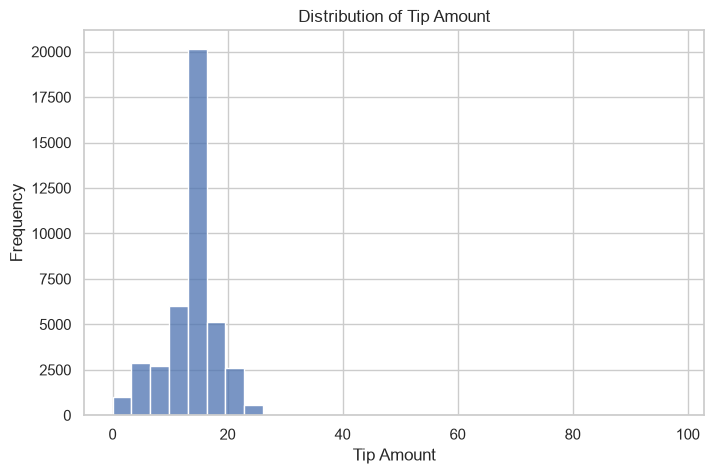

In [3]:
taxi_df = pd.read_csv(TAXI_URL)
print("Taxi database shape: ", taxi_df.shape)
print("First rows:", taxi_df.head() )
print("Taxi info", taxi_df.info())
print("Taxi's missing values", taxi_df.isna().sum())
plt.figure(figsize =(8,5))
sns.histplot(taxi_df["tip_amount"],bins = 30)
plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.show()


### It is bell shaped and unimodal. With a peak around 15 or 16. It is slightly right-skewed as the values extend further on the right. There are no obvious extreme outliers

### Part 1.2 - Preprocessing & feature engineering

In [4]:
missing_values = taxi_df.isna().sum()
print(missing_values)

print(sum(taxi_df["fare_amount"] <= 0))
print(sum(taxi_df["tip_amount"] <= 0))
print(sum(taxi_df["trip_distance"] <= 0))
cleaned_taxi = taxi_df[taxi_df["trip_distance" ] > 0]
print(sum(cleaned_taxi["trip_distance"] <= 0))

cleaned_taxi["fare_per_mile"]= cleaned_taxi["fare_amount"]/ cleaned_taxi["trip_distance"]
print(cleaned_taxi["fare_per_mile"].head())

cleaned_taxi["total_surcharges"] = cleaned_taxi["mta_tax"] + cleaned_taxi["tolls_amount"] + cleaned_taxi["improvement_surcharge"]

print(cleaned_taxi["total_surcharges"].head())

categorical_columns = ["VendorID", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type"]

encoded_taxi = pd.get_dummies(cleaned_taxi, columns=categorical_columns)

numerical_features = ["passenger_count", "trip_distance", "fare_amount", "mta_tax", "tolls_amount", "improvement_surcharge", "total_surcharges", "fare_per_mile"]







VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64
0
0
76
0
0    3.970505
1    3.586066
2    3.930376
3    3.626943
4    3.733333
Name: fare_per_mile, dtype: float64
0    8.44
1    8.44
2    8.44
3    1.50
4    8.44
Name: total_surcharges, dtype: float64


### Student Reasoning: 
1. I first checked  the dataset for missing values using missing_values = taxi_df.isna().sum() and found there were no missing values in the dataset. I then checked for invalid vlaues and found 76 rows of trip_distance were invalid using print(sum(taxi_df["trip_distance"] <= 0)). Since a taxi trip cannot have a distance of zero or less, i filtered that column to remove those rows to improve the quality of the dataset.

2. I engineered the total_surcharges and fare_per_mile features. The fare_per_mile was calculating by dividing the fare_amount by the trip_distance.This represents the cost of the trip per mile, which may help explain differences in tipping behavior. The total_surcharges feature was created by adding mta_tax, tolls_amount, and improvement_surcharge together. This captures the total additional charges on a trip, which may also influence how much a passenger tips.


3. I chose the StandardScaler because it scales the numeric features to standard values on a similar range by centering them around the mean of 0 and an s.d of 1. This will help the agent and machine learning algorithms perform better since the features with larger values will not greatly affect those with smaller values.

In [5]:
cleaned_taxi.dtypes

VendorID                   int64
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag         int64
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
mta_tax                  float64
tolls_amount             float64
improvement_surcharge      int64
tip_amount               float64
fare_per_mile            float64
total_surcharges         float64
dtype: object

Student Reasoning: 1. I handled missing values by removing them from the set because from the set, 76 records have distances <= 0 . and since trip distance cannot have a negative value and a value of 0, these reccords were considered invalid and removed from the dataset

## Part 1.3 - Train / Validation / Test split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X= encoded_taxi.drop(columns =["tip_amount"])
y = encoded_taxi["tip_amount"]


#First split :  80% temp, 20% training
X_temp, X_test, y_temp, y_test = train_test_split(X,y, random_state = 42, test_size = 0.20, shuffle = True )


# Second split: 60% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp, random_state = 42, test_size = 0.25, shuffle = True )

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

scaler =StandardScaler()
scaler.fit(X_train)
X_train_transformed = scaler.transform(X_train)
X_val_transformed = scaler.transform(X_val)
X_test_transformed = scaler.transform(X_test)

(24675, 276)
(8225, 276)
(8226, 276)


### Student Reasoning - Splitting
1. I used a 60/20/20 split. I initially split the data into 80% temporary data and 20% test data. Then i split the temporary data into 75% and 25% validation, which led to 60% training, 20% validation and 20% test.

2. A separate validation set is useful in addition to a test set because itallows us to tune, compare and improve models without using the test set. The test set is reserved for final evaluation, so keeping it separate provides an unbiased measure of how well the model performs on unseen data.

3.This is because they learn information from the data, such as mean and standard deviation. If the validation or test are also used during fitting, information from those set leaks into the training process, leading to data leakage.


### Part 1.4 - Train a regressor and check for overfitting

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

regressor = LinearRegression()
regressor.fit(X_train, y_train)
regressor_predict_train = regressor.predict(X_train)
regressor_predict_val = regressor.predict(X_val)
regressor_predict_test = regressor.predict(X_test)

train_mse = mean_squared_error(y_train, regressor_predict_train)
val_mse = mean_squared_error(y_val, regressor_predict_val)
test_mse = mean_squared_error(y_test, regressor_predict_test)

train_rmse = train_mse ** 0.5
val_rmse = val_mse ** 0.5
test_rmse =  test_mse ** 0.5

train_r2 = r2_score(y_train, regressor_predict_train )
val_r2 = r2_score(y_val, regressor_predict_val)
test_r2 = r2_score(y_test, regressor_predict_test)

print(train_rmse)
print(val_rmse)
print(test_rmse)
print(train_r2)
print(val_r2)
print(test_r2)



4.7764043959631435
5.046273856615029
5.013199306047298
0.062372226553790155
0.045179894867610315
0.05105434390889241


### Student Reasoning - Regression evaluation & overfitting

1. I used a Linear Regression model and evaluated it on the training, validation and test sets. I did not use any hyper-parameters because Linear Regression has very few tunable festures compared to other models. Since only Linear Regression was evaluated, it was the best-performing model among the models tested.

2. The model appears to be underfitting than overfitting. The RMSE values are similar across all three datasets
* Train RMSE = 4.776
*Validation RMSE = 5.046
* Test RMSE = 5.013

The R² values are also similar
* Train R² = 0.06
* Validation R² = 0.045
* Test R² = 0.051
Since the training and validation/test performances are very close, the model is not overfitting. However, the R² values are very low (around 0.05), meaning the model explains only about 5% of the variation in tip amounts. This suggests that the model is too simple to capture the underlying patterns in the data and is therefore underfitting.

3. If i observed overfitting, i would:
*Try using a simpler model
* Reduce the model complexity
* Increase the amount of training data

## Section 2 - Supervised Learning: Multi - class Classification

### Predicting obesity level(NObeyesdad)

### Part 2.1 - Load and explore the obesity data

Obesity database shape:  (2111, 17)
First rows:    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        

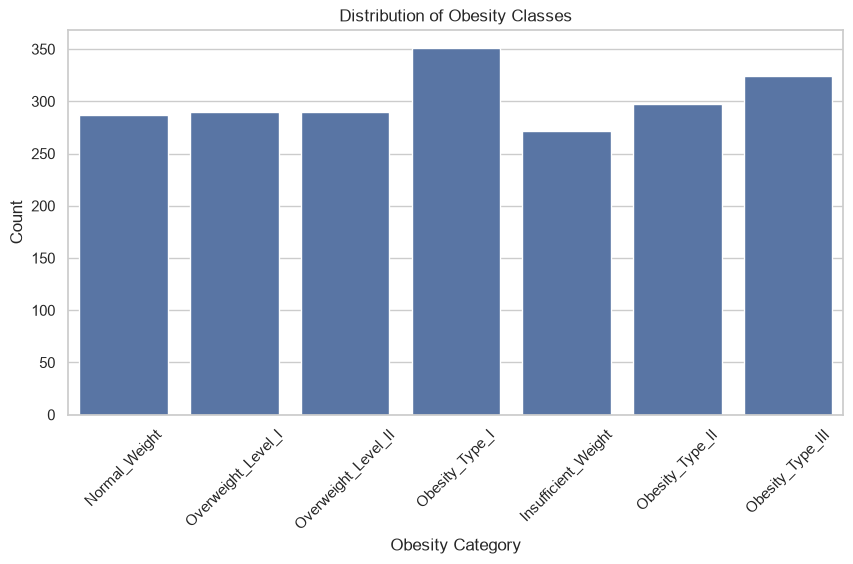

In [8]:
obesity_df = pd.read_csv(OBESITY_URL)
print("Obesity database shape: ", obesity_df.shape)
print("First rows:", obesity_df.head() )
print("Obesity info:" )
obesity_df.info()
print("Obesity's missing values", obesity_df.isna().sum())
obesity_df["NObeyesdad"].value_counts()
plt.figure(figsize=(10,5))
sns.countplot(data=obesity_df, x="NObeyesdad")
plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



### Student Reasoning - Obesity data exploration

1.There are 2111 rows(observations) and 17 columns(features) including the target variable NObeyesdad.
2.The  categorical columns include:
* Gender                 *family_history_with_overweight

* FAVC                    *CAEC

*SCC                       *CALC

*SMOKE                      *MTRANS

*NObeyesdad (target variable)

Numeric columns include
* Age                       * NCP

* height                    * CH2O

* Weight                     *FAF

* FCVC                        *TUE
3. The target is balanced across the 7 classes.The class counts range from 272 observations (Insufficient_Weight) to 351 observations (Obesity_Type_I), which is a relatively small difference.

Class balance is important because an imbalanced dataset can cause a classifier to favor the majority class and ignore minority classes. This may lead to misleadingly high accuracy while performing poorly on underrepresented classes. A balanced dataset helps the model learn all classes more fairly and improves classification performance.

### Part 2.2 - Preprocessing & feature engineering

In [9]:
#Encode categorical columns
#Binary yes/no columns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

obesity_df["family_history_with_overweight"] = obesity_df["family_history_with_overweight"].map({"yes": 1, "no": 0})

obesity_df["family_history_with_overweight"].unique()

#FAVC
obesity_df["FAVC"] = obesity_df["FAVC"].map({"yes" : 1, "no": 0})

#SMOKE
obesity_df["SMOKE"] = obesity_df["SMOKE"].map({"yes" : 1, "no": 0})

#SCC
obesity_df["SCC"] = obesity_df["SCC"].map({"yes" : 1, "no": 0})

obesity_df["Gender"] = obesity_df["Gender"].map({"Female" : 1, "Male": 0})

#Verification
print(obesity_df["family_history_with_overweight"].unique())
print(obesity_df["FAVC"].unique())
print(obesity_df["SMOKE"].unique())
print(obesity_df["SCC"].unique())
print(obesity_df["Gender"].unique())

#Ordinal-ish columns
obesity_df["CAEC"] = obesity_df["CAEC"].map({"no" : 0, "Sometimes": 1, "Frequently": 2, "Always": 3})

obesity_df["CALC"] = obesity_df["CALC"].map({"no" : 0, "Sometimes": 1, "Frequently": 2, "Always": 3})


#TODO (optional but encouraged): engineer a domain feature
obesity_df["BMI"] = obesity_df["Weight"] / (obesity_df["Height"])**2

encoded_obesity = pd.get_dummies(obesity_df, columns=["MTRANS"])


obesity_df["CAEC"].unique()
obesity_df["CALC"].unique()
encoded_obesity.head()

# TODO: Encode the target `NObeyesdad` into integer class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(obesity_df["NObeyesdad"])
X = encoded_obesity.drop(columns=["NObeyesdad"])
y = y_encoded

X_temp, X_test, y_temp, y_test = train_test_split( X, y,
random_state=42,test_size=0.20,shuffle=True)

X_train, X_val, y_train, y_val = train_test_split( X_temp,y_temp,random_state=42,test_size=0.25,shuffle=True)

standard_scaler = StandardScaler()
standard_scaler.fit(X_train)
X_train_scaled = standard_scaler.transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)



[1 0]
[0 1]
[0 1]
[0 1]
[1 0]


In [10]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(1266, 21)
(422, 21)
(423, 21)


#   Discuss whether including BMI makes the task "too easy" / leaks the target.
I created a BMI feature using BMI = Weight / Height². BMI summarizes the relationship between height and weight and is strongly related to obesity. Including BMI does not cause data leakage because it is calculated from existing input features (Height and Weight) rather than the target variable. However, it may make the classification task easier because obesity categories are closely associated with BMI.

In [11]:
obesity_df[["Weight", "Height", "BMI"]].head()

,Weight,Height,BMI
0,64.0,1.62,24.386526
1,56.0,1.52,24.238227
2,77.0,1.80,23.765432
3,87.0,1.80,26.851852
4,89.8,1.78,28.342381


In [12]:
print(y_encoded[:10])
print(label_encoder.classes_)

[1 1 1 5 6 1 1 1 1 1]
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


### Student Reasoning- Obesity preprocessing

1. I used different encoding methods depending on the type of categorical variable.

* For the bianry variables (family_history_with_overweight, FAVC, SMOKE, and SCC), I used binary encoding by mapping yes = 1 and no = 0. 

* For Gender, I used binary encoding (Female = 1, Male = 0) because it contains only two categories.

* For ordinal variables(CAEC and CALC), I used ordinal encoding by the mapping:
no = 0
Sometimes = 1
Frequently = 2
Always = 3

* For the nominal variable, MITRANS, i used one-hot encoding with pd.get_dummies(). Transportation methods do not have a natural order, so one-hot encoding prevents the model from assuming any ranking among them.

* For the target variable NObeyesdad, I used LabelEncoder() to convert the obesity classes into integer labels that be used by the machine learning algorithms.

### Part 2.3 - Stratified Train / Validation / Test split

In [13]:
X_temp, X_test,y_temp, y_test = train_test_split( X, y,
random_state=42,test_size=0.20,shuffle=True, stratify = y)

X_train, X_val, y_train, y_val = train_test_split( X_temp,y_temp,random_state=42,test_size=0.25,shuffle=True, stratify = y_temp)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(len(set(y_train)))
print(len(set(y_val)))
print(len(set(y_test)))

(1266, 21)
(422, 21)
(423, 21)
7
7
7


### Student Reasoning - Splitting

* . I used 60% training, 20% validation, and 20% test split ratio. To achieve this ratio, I first split the data into 80% temporary data and 20% test split (test_size = 0.20). I then split the temporary data into 75% training and 25% validation (test_size = 0.25)

* Stratify = y is important for the dataset because the dataset contains 7 obesity classes. Stratification ensures that each of the class appears in approximately the same proportion in training, validation, and test sets as in the origional dataset.

* Without stratification, some obesity classes could be overrepresented or underrepresented in certain splits.In extreme cases, a class might be missing from the validation or test set entirely. This would lead to an unfair evaluation of the model and could reduce its ability to generalize to all obesity classes.

### Part 2.4 - Train a classifier and check for overfitting


0.20853080568720378
0.13033175355450238
0.15839243498817968
0.1962996435659697
0.1259724084602501
0.1499741382228815
0.9944707740916272
0.15165876777251186
0.13711583924349882
0.994242023325063
0.1519194757696094
0.1363349817882716


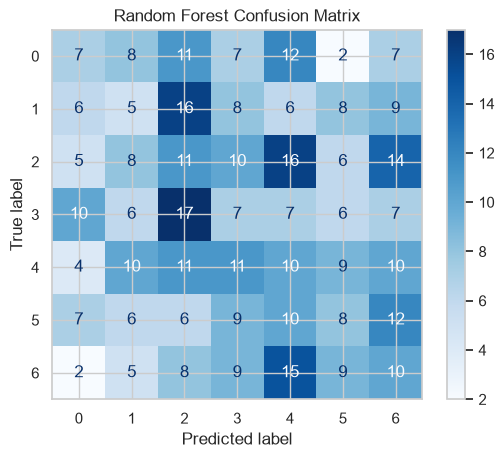

In [14]:
# Import, initialise, and train a classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

logistic_regressor = LogisticRegression(max_iter=1000)

#  Predict on train, validation, and test.
logistic_regressor.fit(X_train_scaled, y_train)

logistic_regressor_predict_train = logistic_regressor.predict(X_train_scaled)

logistic_regressor_predict_val = logistic_regressor.predict(X_val_scaled)

logistic_regressor_predict_test = logistic_regressor.predict(X_test_scaled)

# Report accuracy  and macro-F1 for all three sets
train_accuracy = accuracy_score(y_train, logistic_regressor_predict_train)

val_accuracy = accuracy_score(y_val, logistic_regressor_predict_val)

test_accuracy = accuracy_score(y_test, logistic_regressor_predict_test)

train_f1_score = f1_score(y_train, logistic_regressor_predict_train, average="macro")

val_f1_score = f1_score(y_val, logistic_regressor_predict_val, average="macro")

test_f1_score = f1_score(y_test, logistic_regressor_predict_test, average="macro")

print(train_accuracy)
print(val_accuracy)
print(test_accuracy)

print(train_f1_score)
print(val_f1_score)
print(test_f1_score)

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

random_forest.fit(X_train_scaled, y_train)

random_forest_predict_train = random_forest.predict(X_train_scaled)

random_forest_predict_val = random_forest.predict(X_val_scaled)

random_forest_predict_test= random_forest.predict(X_test_scaled)

train_accuracy_forest = accuracy_score(y_train, random_forest_predict_train)

val_accuracy_forest= accuracy_score(y_val, random_forest_predict_val)

test_accuracy_forest= accuracy_score(y_test, random_forest_predict_test)

train_f1_score_forest = f1_score(y_train, random_forest_predict_train, average="macro")

val_f1_score_forest = f1_score(y_val, random_forest_predict_val, average="macro")

test_f1_score_forest = f1_score(y_test, random_forest_predict_test, average="macro")


print(train_accuracy_forest)
print(val_accuracy_forest)
print(test_accuracy_forest)

print(train_f1_score_forest)
print(val_f1_score_forest)
print(test_f1_score_forest)

ConfusionMatrixDisplay.from_estimator(random_forest,
X_test_scaled, y_test, cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

### Student Reasoning - Classification evaluation and overfitting

* I used both a Logistic Regression classifier and a Random Forest classifier. I selected the Random Forest classifier because it achieved a sligthly higher validation accuracy and is capable of capturing more complex relationships in the obesity dataset.

* The Logistic Regression model achieved a training accuracy of 20.85%, validation accuracy of 13.03%, and test accuracy of 15.84%. Its macro-F1 scores were 19.63%, 12.60%, and 15.00% respectively, indicating underfitting.
The Random Forest model achieved a training accuracy of 99.45%, validation accuracy of 15.17%, and test accuracy of 13.71%. Its macro-F1 scores were 99.42%, 15.19%, and 13.63% respectively.
The Random Forest model is overfitting because its training performance is almost perfect while its validation and test performance are much lower. The large gap between the training accuracy (99.45%) and validation accuracy (15.17%) shows that the model memorized the training data instead of generalizing well to unseen data.

* The confusion matrix shows that the model most frequently confuses obesity levels that are close to each other, such as Normal Weight and Overweight Level I or Overweight Level I and Overweight Level II (replace these with the actual classes from your matrix if different). These classes are difficult to distinguish because their characteristics, such as weight, BMI, eating habits, and physical activity levels, may be very similar. As a result, the classifier struggles to identify clear boundaries between neighboring obesity categories

## Section 3 - Unsupervised Learning: K - Means Clustering

### Discovering hidden groups in the obesity data

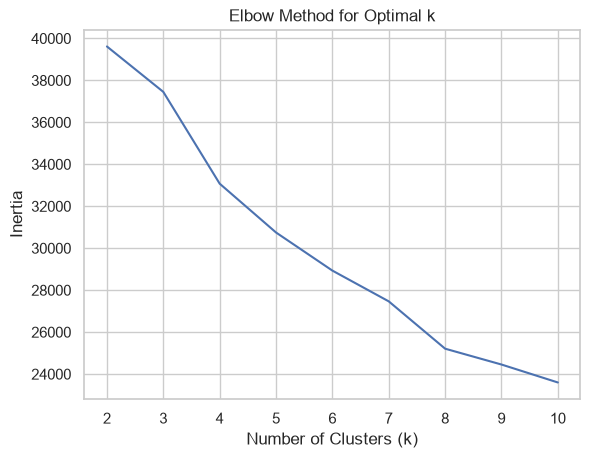

[0 0 0 0 0 1 0 0 3 3]
(2111, 2)


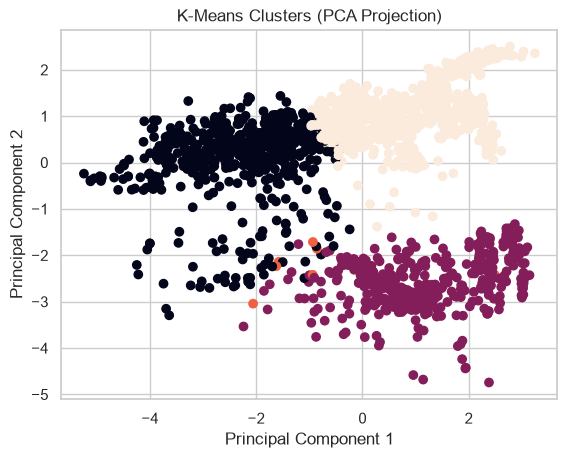

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,226,228,7,1,0,99,70
1,45,35,113,95,1,67,96
2,0,4,0,1,0,2,0
3,1,20,231,200,323,122,124


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
standard_scaler = StandardScaler()
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

obesity_scaled = standard_scaler.fit_transform(X)
inertias = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(obesity_scaled)
  inertias.append( kmeans.inertia_ )

k_values = range(2, 11)
plt.plot(k_values, inertias)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(obesity_scaled)
print(cluster_labels[:10])
pd.Series(cluster_labels).value_counts()

pca = PCA(n_components=2)
obesity_pca = pca.fit_transform(obesity_scaled)
print(obesity_pca.shape)
obesity_pca[:,0]
obesity_pca[:,1]
plt.scatter(obesity_pca[:,0],obesity_pca[:,1],c=cluster_labels)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.show()

pd.crosstab(cluster_labels, obesity_df["NObeyesdad"])

### Student Reasoning - Clustering

* I used the Elbow Method to determine the optimal number of clusters. I plotted inertia against different values of k (2–10) and observed that the inertia decreased rapidly from k = 2 to k = 4, after which the curve began to flatten. This indicated diminishing returns from adding more clusters. Therefore, I selected k = 4 because it represented the elbow point where increasing the number of clusters provided only small improvements.

* The clusters partially resembled the true obesity levels. Cluster 0 mainly contained Insufficient Weight and Normal Weight individuals, while Cluster 3 contained a large number of Obesity Type I, Obesity Type II, and Obesity Type III individuals. This suggests that K-Means was able to separate lower-weight and higher-weight groups reasonably well.
However, the clustering was not perfect. Some clusters contained a mixture of Overweight Level I, Overweight Level II, and Obesity Type I individuals. This indicates that people in neighboring obesity categories share similar characteristics, making it difficult for K-Means to separate them completely. In addition, one cluster contained only 7 observations, suggesting the presence of outliers.

* In a public-health setting, these clusters could be used to identify groups of people with similar health and lifestyle characteristics without requiring obesity labels. Health organizations could use the clusters to target interventions, design wellness programs, allocate resources, and identify high-risk populations. Even without labeled data, clustering can help discover patterns in the population and support decision-making for prevention and health promotion initiatives.

## Section 4 - Reflection

### 1. Supervised vs Unsupervised

The classifier learned how features relate to obesity labels and could predict obesity categories. K-Means did not use labels and instead discovered natural groups in the data.

### 2. Regression vs Classification

Regression predicted a continuous value (tip amount) and was evaluated using RMSE, MSE, and R². Classification predicted obesity categories and was evaluated using Accuracy, F1-score, and the Confusion Matrix.

### 3. Overfitting

The biggest train-test gap occurred with the Random Forest classifier. It achieved about 99.45% training accuracy but only 13.71% test accuracy, showing severe overfitting. To reduce this, I would tune the model's hyperparameters and use cross-validation.